In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel(r"C:\Users\user\OneDrive\Documents\D_I_G\ML\Timeseries\Well_Data\WWS1, 2023.xlsx")
df.iloc[:500:24*15,:]

,Well ID,Date,Time,Distance,Pump Time,Level,InvPumpTime,Unnamed: 7
0,WWS1,2023-01-02,12:30:00,204,587,196.0,313,27.042904
360,WWS1,2023-01-06,07:30:00,201,894,199.0,6,NaN


In [3]:
print(f'well id WWS1 num observations: {df.loc[df['Well ID']=='WWS1'].shape[0]}')
print(f'total observations {df.shape[0]}')

well id WWS1 num observations: 20171
total observations 20171


In [4]:
df['datetime']=df['Date'].astype(str)+' '+df['Time'].astype(str)
df['datetime']=pd.to_datetime(df['datetime'],yearfirst=True,format='%Y-%m-%d %H:%M:%S')
df.sample()

,Well ID,Date,Time,Distance,Pump Time,Level,InvPumpTime,Unnamed: 7,datetime
15600,WWS1,2023-06-15,09:15:00,254,894,146.0,6,NaN,2023-06-15 09:15:00


In [5]:
df['year']=df['datetime'].dt.year
df['day_of_year']=df['datetime'].dt.dayofyear
df.sample()

,Well ID,Date,Time,Distance,Pump Time,Level,InvPumpTime,Unnamed: 7,datetime,year,day_of_year
8859,WWS1,2023-04-05,14:15:00,252,893,148.0,7,NaN,2023-04-05 14:15:00,2023,95


In [6]:
df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')
df.loc[df['Distance']=='na','Distance'].interpolate(method='linear')

Series([], Name: Distance, dtype: float64)

max-avg-std<0
avg-min-std<0

In [7]:
def roll(dataframe,periods:int=20,variable:str='Distance'):
    data=dataframe.copy()
    mn=f"{periods}period min"
    avg=f"{periods}period avg"
    mx=f"{periods}period max"
    std=f"{periods}period std"
    #data['is valid']=np.zeros(data.shape[0])
    #is_val_NaN=data['is valid'].isna().sum().sum()/data.shape[0]

    #while is_val_NaN<.5:
    data[mn]=data[variable].rolling(window=periods,center=True).min()
    data[avg]=data[variable].rolling(window=periods,center=True).mean()
    data[mx]=data[variable].rolling(window=periods,center=True).max()
    data[std]=data[variable].rolling(window=periods,center=True).std()
    def get_true(dis,avg,std):
        if (abs(dis-avg) <= abs(std)) and dis>avg: return dis
        else: return np.nan
    data['is valid']=data.apply(lambda row: get_true(row[variable],row[avg],row[std]),axis=1)

    #is_val_NaN=data['is valid'].isna().sum().sum()/data.shape[0]
    #periods+=5
    print('periods: ',periods)
    plt.figure(figsize=(20,4))
    #data['Distance'].plot()
    data['is valid'].plot(x='datetime')
    
    plt.legend()
    plt.show()

periods:  12


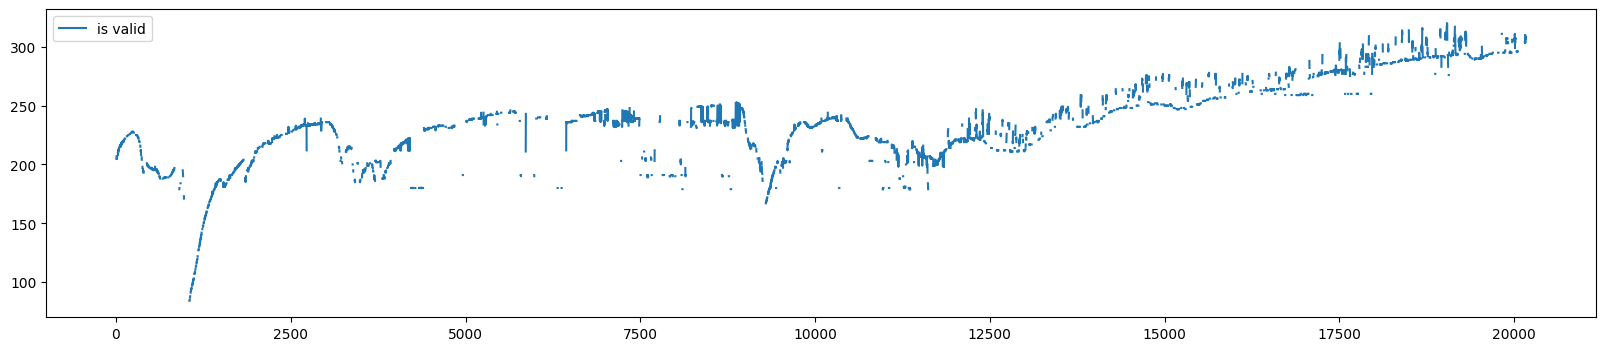

In [8]:
roll(df,12)

mean: 250


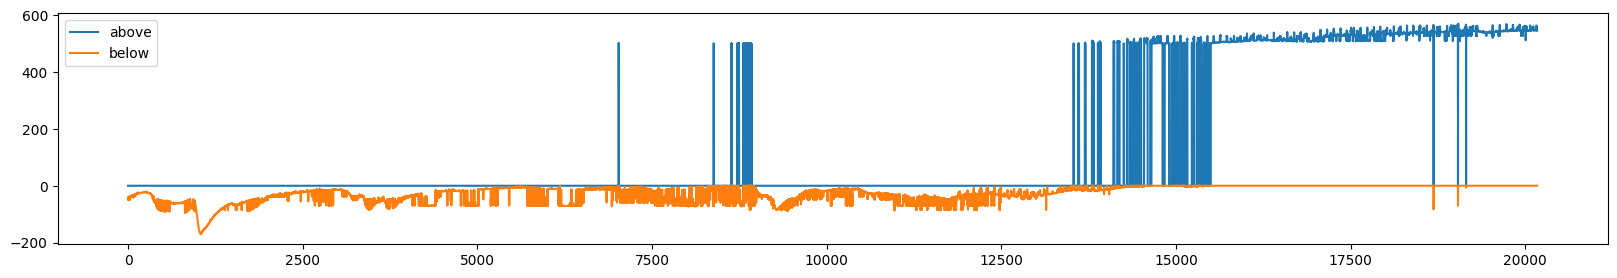

In [9]:
mean=250#df['Distance'].mean()
print(f'mean: {mean}')

plt.rcParams['figure.figsize']=(20,3)
df['above']=np.zeros(df.shape[0])
df['below']=np.zeros(df.shape[0])
abmask=df['Distance']>mean
blmask=df['Distance']<mean
df.loc[abmask,'above']=df.loc[abmask,'Distance']+mean
df.loc[blmask,'below']=df.loc[blmask,'Distance']-mean
df['above'].plot(label='above')
df['below'].plot()
plt.legend()

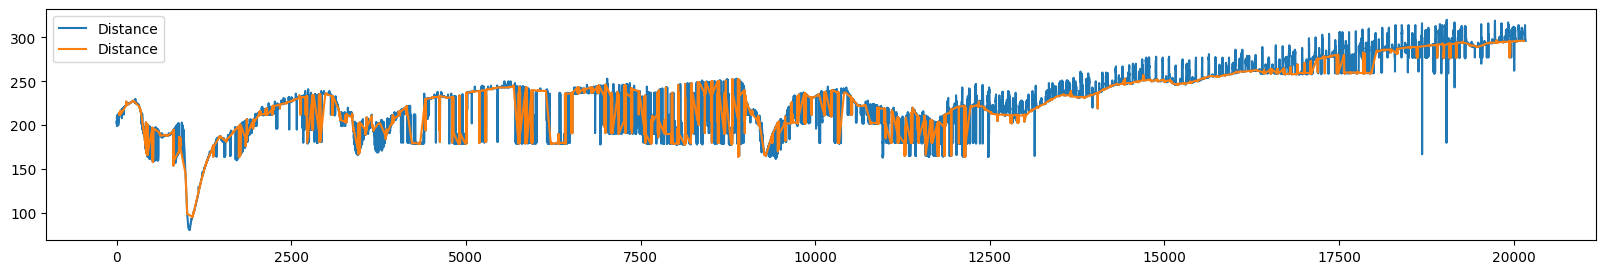

In [10]:
from datetime import time
start_time=time(4,30)
end_time=time(22,0)
pltdf=df.loc[(df['Time']<start_time)|(df['Time']>end_time)]
x=pltdf['datetime']
y=pltdf['Distance']
df['Distance'].plot()
pltdf['Distance'].plot()

plt.legend()

periods:  12


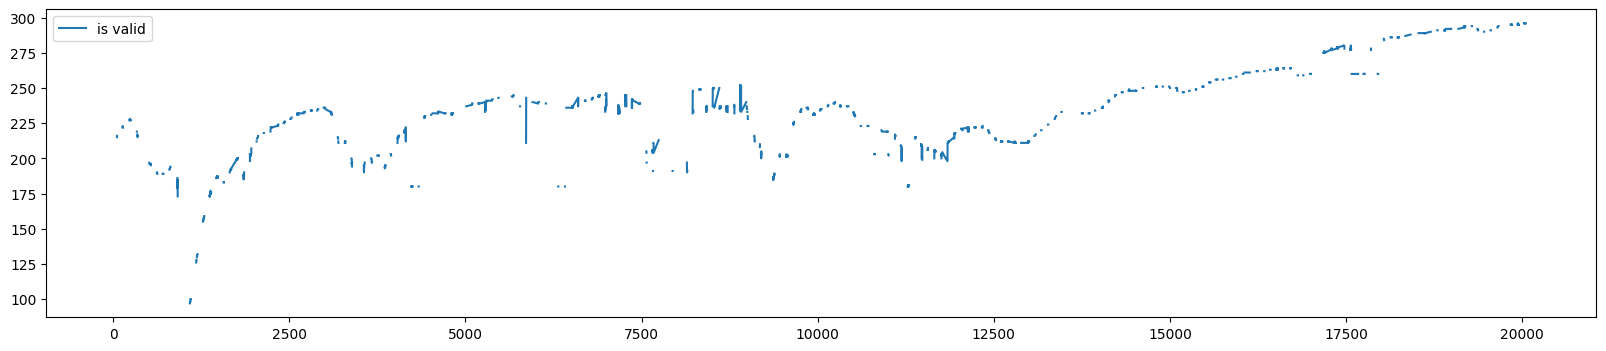

In [11]:
roll(pltdf,12)

periods:  12


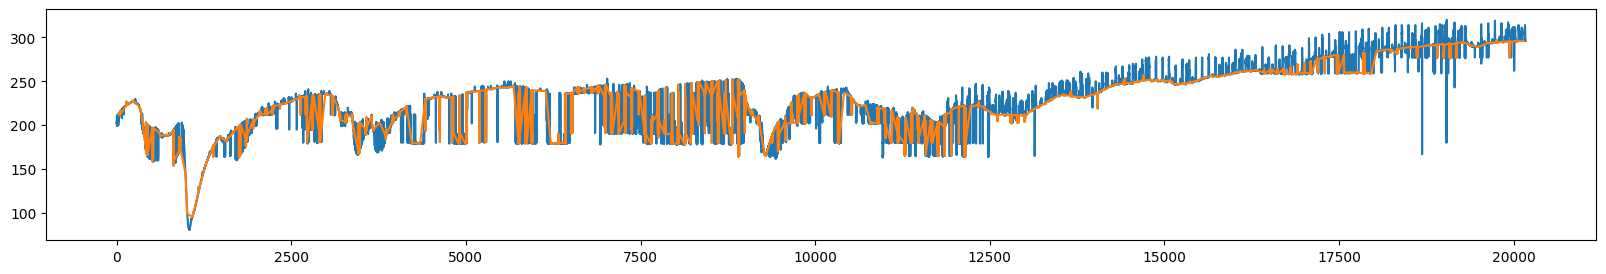

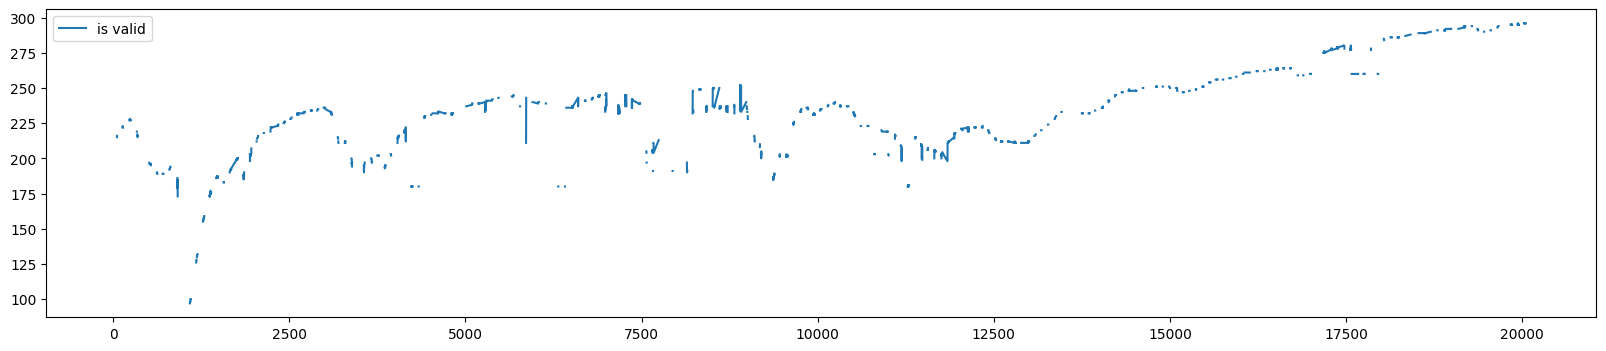

In [12]:
from datetime import time
start_time=time(4,30)
end_time=time(22,0)
pltdf=df.loc[(df['Time']<start_time)|(df['Time']>end_time)]
x=pltdf['datetime']
y=pltdf['Distance']
df['Distance'].plot()
pltdf['Distance'].plot()
roll(pltdf,12)

In [13]:
from datetime import time
def night_only(dataframe,var:str='Distance',morning:tuple=(4,3),evening:tuple=(22,0)):
    nightdf=dataframe.copy()
    start_time=time(*morning)
    end_time=time(*evening)
    nightdf['targets']=np.nan
    mask=(nightdf['Time']<start_time)|(nightdf['Time']>end_time)
    nightdf.loc[mask,'targets']=nightdf.loc[mask,var]
    nightdf=nightdf.loc[(nightdf['Time']<start_time)|(nightdf['Time']>end_time)]
    return nightdf
def window(dataframe,periods:int=20,variable:str='Distance'):
    data=dataframe.copy()
    mn=f"{periods}period min"
    avg=f"{periods}period avg"
    mx=f"{periods}period max"
    std=f"{periods}period std"
    data[mn]=data[variable].rolling(window=periods,center=True).min()
    data[avg]=data[variable].rolling(window=periods,center=True).mean()
    data[mx]=data[variable].rolling(window=periods,center=True).max()
    data[std]=data[variable].rolling(window=periods,center=True).std()
    def get_true(dis,avg,std):
        if (abs(dis-avg) <= abs(std)) and dis>avg: return dis
        else: return np.nan
    data['is valid']=data.apply(lambda row: get_true(row[variable],row[avg],row[std]),axis=1)
    return data


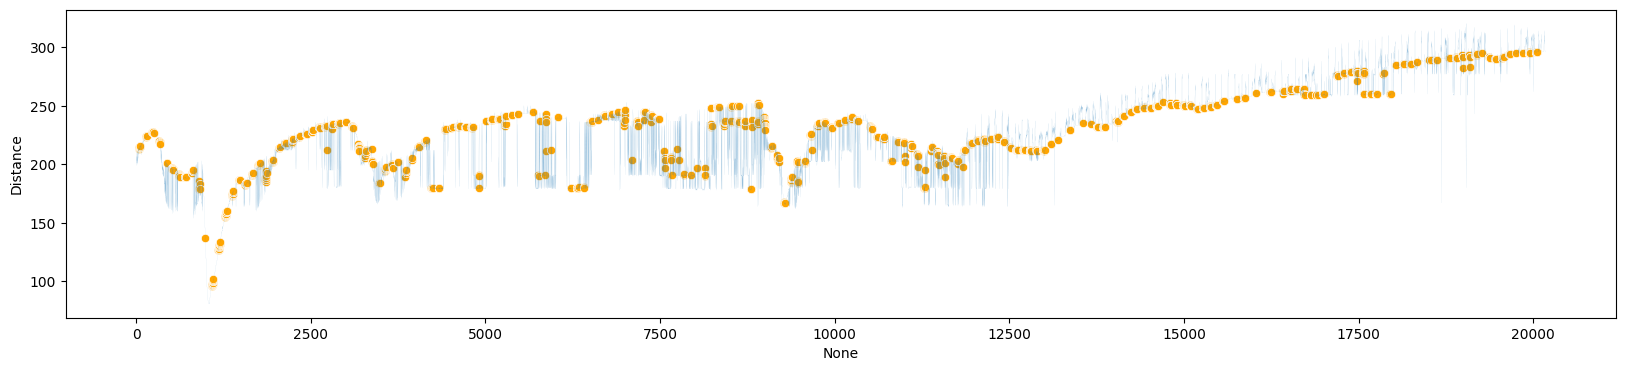

In [14]:
df=df.sort_values(by='datetime').reset_index(drop=True)
x=df.index
target_data=df.copy()
target_data=window(target_data,12)
target_data=night_only(target_data,'is valid')
target_data['ordered periods']=target_data.index
plt.figure(figsize=(20,4))
sns.lineplot(x=x,y=df['Distance'],linewidth=0.03)
sns.scatterplot(x=target_data['ordered periods'],y=target_data['targets'],color='orange')
plt.show()

<Axes: xlabel='datetime', ylabel='targets_linFill'>

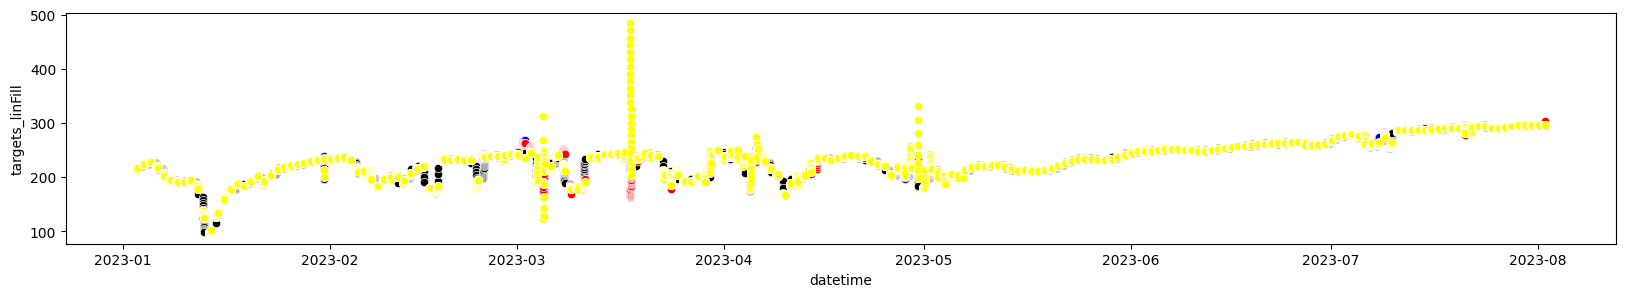

In [55]:
target_data['targets_linFill']=target_data['targets'].interpolate(method='linear')
target_data['targets_spln3']=target_data['targets'].interpolate(method='spline',order=3)
target_data['targets_spln4']=target_data['targets'].interpolate(method='spline',order=4)
target_data['targets_spln5']=target_data['targets'].interpolate(method='spline',order=5)
sns.scatterplot(x=target_data['datetime'],y=target_data['targets_linFill'],color='black')
sns.scatterplot(x=target_data['datetime'],y=target_data['targets_spln3'],color='blue')
sns.scatterplot(x=target_data['datetime'],y=target_data['targets_spln4'],color='red')
sns.scatterplot(x=target_data['datetime'],y=target_data['targets_spln5'],color='yellow')

In [15]:
fuel=target_data.loc[~target_data['targets'].isna()]
fuel['ordered periods']=fuel['ordered periods'].astype(int)
X=fuel[['ordered periods']]
y=fuel['targets']


C:\Users\user\AppData\Local\Temp\ipykernel_27000\742076881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel['ordered periods']=fuel['ordered periods'].astype(int)


In [16]:
for i in X.values:
    print(i)
    print(type(i[0]))
    break
print(X.head())

[43]
<class 'numpy.int32'>
    ordered periods
43               43
44               44
48               48
51               51
53               53


In [35]:
from sklearn.tree import DecisionTreeRegressor


In [18]:
for i in X:
    print(i)
    print(type(i))

ordered periods
<class 'str'>


In [42]:
model=DecisionTreeRegressor(max_leaf_nodes=15)
model.fit(X,y)


DecisionTreeRegressor(max_leaf_nodes=15)

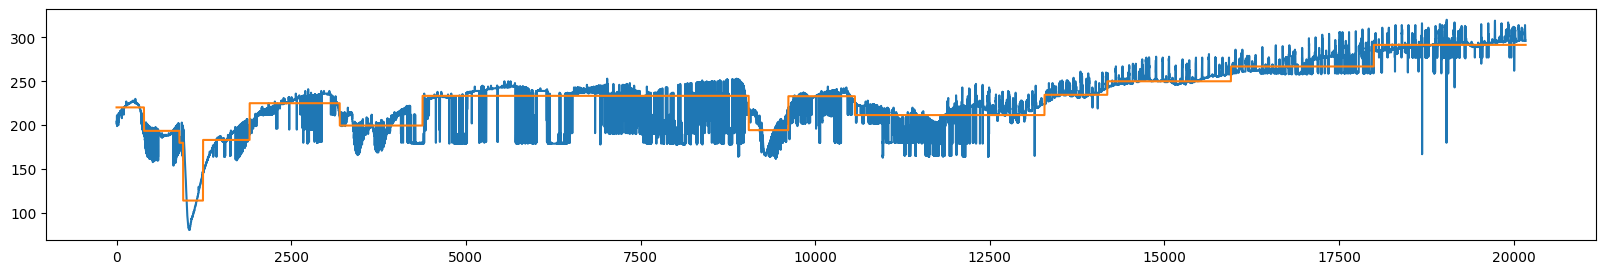

In [43]:
X_pred = np.array(df.index).reshape(-1, 1)
df['pred'] = model.predict(X_pred)

df['Distance'].plot()
df['pred'].plot()
plt.show()

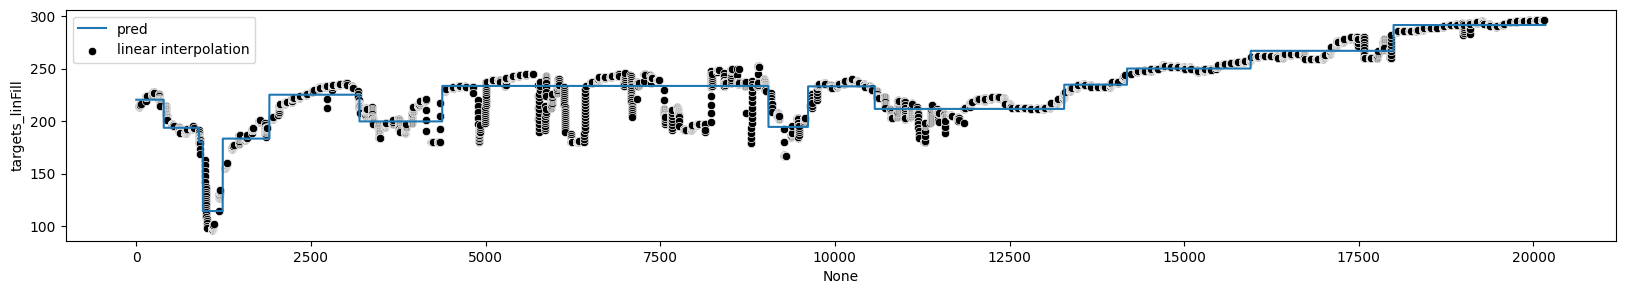

In [59]:
df['pred'].plot()
sns.scatterplot(x=target_data.index,y=target_data['targets_linFill'],color='black',label='linear interpolation')
plt.legend()

In [48]:
import joblib
from joblib import dump,load
joblib.dump(model,'decisionT_well.pkl')

['decisionT_well.pkl']

In [47]:
from sklearn.tree import export_text
r = export_text(model)
print(r)

|--- feature_0 <= 14181.00
|   |--- feature_0 <= 1904.50
|   |   |--- feature_0 <= 899.50
|   |   |   |--- feature_0 <= 392.00
|   |   |   |   |--- value: [220.29]
|   |   |   |--- feature_0 >  392.00
|   |   |   |   |--- value: [193.57]
|   |   |--- feature_0 >  899.50
|   |   |   |--- feature_0 <= 1237.50
|   |   |   |   |--- feature_0 <= 952.50
|   |   |   |   |   |--- value: [180.00]
|   |   |   |   |--- feature_0 >  952.50
|   |   |   |   |   |--- value: [114.26]
|   |   |   |--- feature_0 >  1237.50
|   |   |   |   |--- value: [183.25]
|   |--- feature_0 >  1904.50
|   |   |--- feature_0 <= 9048.00
|   |   |   |--- feature_0 <= 4379.00
|   |   |   |   |--- feature_0 <= 3194.50
|   |   |   |   |   |--- value: [225.06]
|   |   |   |   |--- feature_0 >  3194.50
|   |   |   |   |   |--- value: [199.63]
|   |   |   |--- feature_0 >  4379.00
|   |   |   |   |--- value: [233.42]
|   |   |--- feature_0 >  9048.00
|   |   |   |--- feature_0 <= 9615.50
|   |   |   |   |--- value: [194.40]


[Text(0.65, 0.9285714285714286, 'x[0] <= 14181.0\nsquared_error = 1146.642\nsamples = 1842\nvalue = 230.171'),
 Text(0.4, 0.7857142857142857, 'x[0] <= 1904.5\nsquared_error = 661.212\nsamples = 1362\nvalue = 215.954'),
 Text(0.525, 0.8571428571428572, 'True  '),
 Text(0.2, 0.6428571428571429, 'x[0] <= 899.5\nsquared_error = 1058.47\nsamples = 203\nvalue = 180.133'),
 Text(0.1, 0.5, 'x[0] <= 392.0\nsquared_error = 184.408\nsamples = 75\nvalue = 203.547'),
 Text(0.05, 0.35714285714285715, 'squared_error = 28.061\nsamples = 28\nvalue = 220.286'),
 Text(0.15, 0.35714285714285715, 'squared_error = 11.181\nsamples = 47\nvalue = 193.574'),
 Text(0.3, 0.5, 'x[0] <= 1237.5\nsquared_error = 1061.196\nsamples = 128\nvalue = 166.414'),
 Text(0.25, 0.35714285714285715, 'x[0] <= 952.5\nsquared_error = 744.627\nsamples = 36\nvalue = 123.389'),
 Text(0.2, 0.21428571428571427, 'squared_error = 2.4\nsamples = 5\nvalue = 180.0'),
 Text(0.3, 0.21428571428571427, 'squared_error = 264.062\nsamples = 31\nval

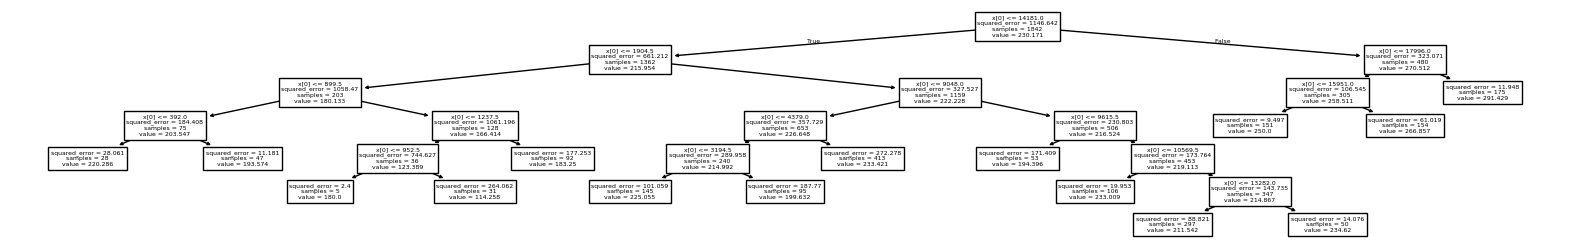

In [45]:
from sklearn.tree import plot_tree
plot_tree(model)

In [49]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
top=0.6806398993597282
#1e-08 26
for reg in [0]:#,0.08,0.001,0.1,0.0001,0.00001,0.000001,1e-6,1e-7,1e-8]:
    for deg in [26]:    
        poly=PolynomialFeatures(degree=deg)
        curr_X=poly.fit_transform(X)
        model2=Lasso(alpha=reg)
        model2.fit(curr_X,y)
        curr_pred=model2.predict(poly.transform(X))
        total_pred=model2.predict(poly.transform(df.index.to_numpy().reshape(-1,1)))
        cur_score=r2_score(y,curr_pred)
        if cur_score>top:
            top=cur_score
            print(cur_score)
            print(reg,deg)

        

0.6806398993597433
0 26


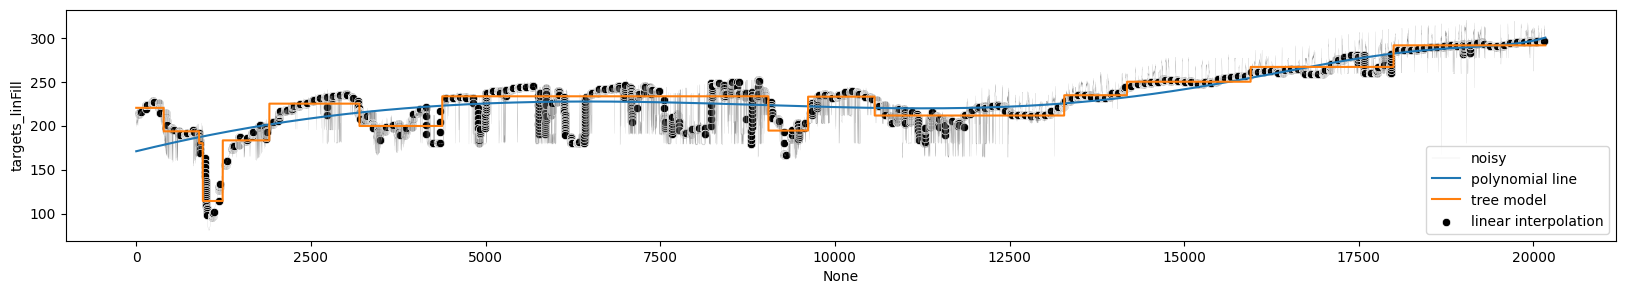

In [62]:
df['Distance'].plot(color='grey',linewidth=0.07,label='noisy')
x=X_pred = np.array(df.index).reshape(-1, )
sns.lineplot(x=x,y=total_pred,label='polynomial line')
df['pred'].plot(label='tree model')
sns.scatterplot(x=target_data.index,y=target_data['targets_linFill'],color='black',label='linear interpolation')
plt.legend()
plt.legend()
plt.show()

In [85]:
poly.powers_

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5],
       [6],
       [7],
       [8],
       [9]], dtype=int64)

In [86]:
poly.n_output_features_

10

In [87]:
print(model2.coef_)
print(model2.intercept_)

[ 0.00000000e+00  1.98442503e-02 -1.94407889e-06  1.84577723e-11
  2.07767740e-15  7.12660959e-20  1.26755234e-24 -2.69710451e-29
 -4.19656360e-33 -2.83090796e-37]
170.62023535300722


In [88]:
y=x^0*0.00000000e+00 +
    x^1*1.98442503e-02 +
    x^2*-1.94407889e-06 +
    x^3*1.84577723e-11 +
    x^4*2.07767740e-15 +
    x^5*7.12660959e-20  + 
    x^6*1.26755234e-24 +
    x^7*-2.69710451e-29 +
    x^8*-4.19656360e-33 +
    x^9*-2.83090796e-37 +
    170.62023535300722


SyntaxError: invalid syntax (4092154153.py, line 1)

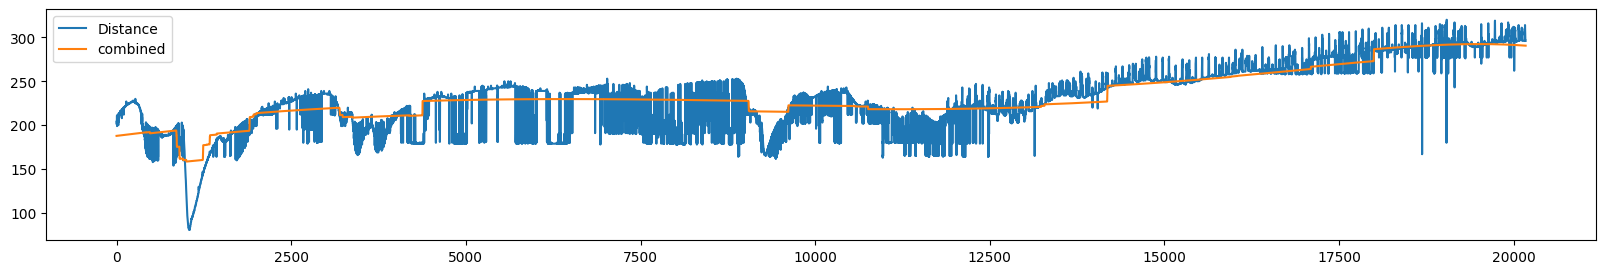

In [89]:
df['combined']=(df['pred']+total_pred)/2
df['Distance'].plot()
df['combined'].plot()
plt.legend()
plt.show()

In [93]:
model.oob_score()

TypeError: 'bool' object is not callable